In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import json
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from datetime import datetime

# Load data
families_df = pd.read_csv("families_data.csv")
inventory_df = pd.read_csv("inventory_data.csv")
distribution_df = pd.read_csv("distribution_history.csv")

In [2]:
# Step 1: Data Cleaning

# Fill missing values
families_df['monthly_income'] = families_df['monthly_income'].fillna(families_df['monthly_income'].median())
families_df['phone'] = families_df['phone'].fillna('Unknown')
families_df['email'] = families_df['email'].fillna('Unknown')

In [3]:
# Fix data types
families_df['adult_ages'] = families_df['adult_ages'].apply(lambda x: json.loads(x) if pd.notnull(x) else [])
families_df['child_ages'] = families_df['child_ages'].apply(lambda x: json.loads(x) if pd.notnull(x) else [])
families_df['registration_date'] = pd.to_datetime(families_df['registration_date'], errors='coerce')
families_df['last_visit'] = pd.to_datetime(families_df['last_visit'], errors='coerce')

In [4]:
# Remove outliers
families_df = families_df[(families_df['adults'] >= 0) & (families_df['adults'] <= 6)]
families_df = families_df[(families_df['monthly_income'] > 0) & (families_df['monthly_income'] < 10000)]

In [5]:
# Standardize text
families_df['dietary_restrictions'] = families_df['dietary_restrictions'].str.lower()
families_df['visit_frequency'] = families_df['visit_frequency'].replace({'Hourly': 'Weekly'})

In [6]:
# Date inconsistencies
families_df.loc[families_df['last_visit'] > pd.Timestamp.now(), 'last_visit'] = pd.Timestamp.now()

In [7]:
# Step 2: Feature Engineering

families_df['dependency_ratio'] = families_df['children'] / (families_df['adults'] + 1)
families_df['household_size_category'] = pd.cut(families_df['total_members'], bins=[0,2,4,6,10], labels=['Small','Medium','Large','Very Large'])
families_df['has_infants'] = families_df['child_ages'].apply(lambda x: any(age < 2 for age in x) if x else False)
families_df['has_seniors'] = families_df['adult_ages'].apply(lambda x: any(age > 65 for age in x) if x else False)

families_df['estimated_calorie_needs'] = (families_df['adults'] * 2000) + (families_df['children'] * 1500)
families_df['protein_needs'] = families_df['total_members'] * 50

families_df['income_per_person'] = families_df['monthly_income'] / families_df['total_members']
families_df['poverty_indicator'] = families_df['income_per_person'] < 500

families_df['days_since_last_visit'] = (pd.Timestamp.now() - families_df['last_visit']).dt.days
visit_map = {'Weekly': 4, 'Bi-weekly': 2, 'Monthly': 1, 'Occasional': 0.5}
families_df['visit_frequency_score'] = families_df['visit_frequency'].map(visit_map)

families_df['num_dietary_restrictions'] = families_df['dietary_restrictions'].apply(lambda x: len(json.loads(x)) if x != "[]" else 0)
families_df['has_special_diet'] = families_df['num_dietary_restrictions'] > 0

In [8]:
# Step 3: Clustering Families

cluster_features = [
    'total_members', 'dependency_ratio', 'income_per_person',
    'num_dietary_restrictions', 'days_since_last_visit',
    'estimated_calorie_needs', 'has_infants', 'has_seniors'
]

X = families_df[cluster_features].fillna(0)
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42)
families_df['need_cluster'] = kmeans.fit_predict(X_scaled)

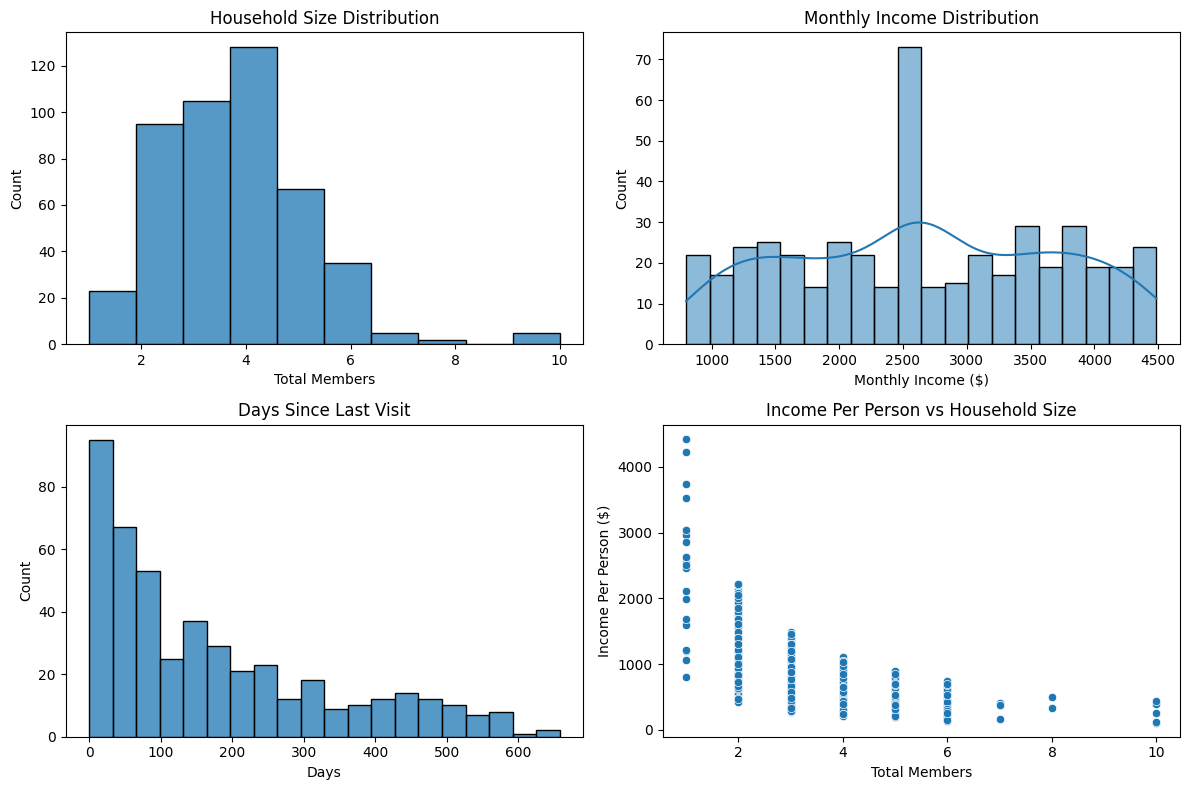

In [9]:
# Step 2.5: Data Analysis (Exploratory)

import matplotlib.pyplot as plt
import seaborn as sns

# 1. Household size distribution
plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
sns.histplot(families_df['total_members'], bins=10)
plt.title('Household Size Distribution')
plt.xlabel('Total Members')

# 2. Monthly income distribution
plt.subplot(2,2,2)
sns.histplot(families_df['monthly_income'], bins=20, kde=True)
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income ($)')

# 3. Days since last visit
plt.subplot(2,2,3)
sns.histplot(families_df['days_since_last_visit'], bins=20)
plt.title('Days Since Last Visit')
plt.xlabel('Days')

# 4. Income per person vs total members
plt.subplot(2,2,4)
sns.scatterplot(x='total_members', y='income_per_person', data=families_df)
plt.title('Income Per Person vs Household Size')
plt.xlabel('Total Members')
plt.ylabel('Income Per Person ($)')
plt.tight_layout()
plt.show()

In [16]:
# Step 4: Clustering Food Inventory

inventory_df['expiry_date'] = pd.to_datetime(inventory_df['expiry_date'], errors='coerce')
inventory_df['days_until_expiry'] = (inventory_df['expiry_date'] - pd.Timestamp.now()).dt.days

food_features = ['calories_per_serving', 'protein_grams', 'days_until_expiry']
category_dummies = pd.get_dummies(inventory_df['category'])
food_clustering_data = pd.concat([inventory_df[food_features].fillna(0), category_dummies], axis=1)

food_kmeans = KMeans(n_clusters=4, random_state=42)
inventory_df['food_cluster'] = food_kmeans.fit_predict(food_clustering_data)

In [18]:
# Step 5: Allocation Simulation

def allocate_food(family_cluster, food_cluster, available_quantity):
    allocation_matrix = {
        0: {0: 1.5, 1: 1.2, 2: 1.0, 3: 0.8},
        1: {0: 1.0, 1: 1.5, 2: 1.2, 3: 1.0},
        2: {0: 0.8, 1: 1.0, 2: 1.2, 3: 1.5},
        3: {0: 1.2, 1: 1.1, 2: 1.0, 3: 0.9},
        4: {0: 0.9, 1: 1.0, 2: 1.1, 3: 1.2}
    }
    priority = allocation_matrix.get(family_cluster, {}).get(food_cluster, 1.0)
    return min(available_quantity, max(1, int(available_quantity * priority)))

allocation_examples = []
for fam in families_df.head(5).itertuples():
    for food in inventory_df.head(5).itertuples():
        qty = allocate_food(fam.need_cluster, food.food_cluster, food.quantity)
        allocation_examples.append({
            'family_id': fam.family_id,
            'food_item': food.item_name,
            'allocated_qty': qty
        })

allocation_df = pd.DataFrame(allocation_examples)
allocation_df.head()

,family_id,food_item,allocated_qty
0,FAM_0001,Milk,90
1,FAM_0001,Peanut Butter,20
2,FAM_0001,Tea,68
3,FAM_0001,Frozen Meals,82
4,FAM_0001,Mayo,25
